In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from fontTools.afmLib import kernRE

opencv读图方法

OpenCV 读取彩色图的通道顺序是 BGR（蓝、绿、红）

In [2]:
# 读取图像
img = cv.imread('2.jpg',1)#0：灰度图，1(默认)：彩图，-1：原样加载

# 显示图像
cv.imshow('2',img)
cv.waitKey(0)#无限期等待

-1

 matplotlib 读图方法

Matplotlib 读取彩色图的通道顺序是 RGB

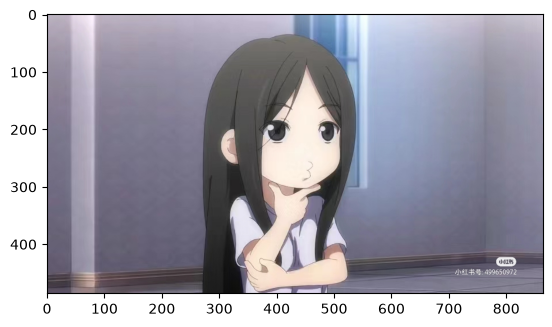

True

In [3]:
plt.imshow(img[:,:,::-1])
#plt.imshow(img,cmap='gray')
plt.show()
#图像保存
cv.imwrite('2.png',img)

切片语法拆解：[:, :, ::-1]

这里的三个部分分别对应数组的三个维度：

第一个 _**:**_-代表高度（行）。意思是“取所有的行”。

第二个 _**:**_-代表宽度（列）。意思是“取所有的列”。

第三个 **_::-1_**-代表颜色通道。这是 Python 中非常强大的逆序（反转）切片语法。它表示从最后一个元素开始，倒着取到第一个元素。

如果原本的通道顺序是 [B, G, R]，经过 ::-1 反转后，就变成了 [R, G, B]。这样就完美地把 BGR 转换成了 RGB。

反转通道，函数：cv2.cvtColor(img, cv2.COLOR_BGR2RGB)= [:,:,::-1]

绘制图像

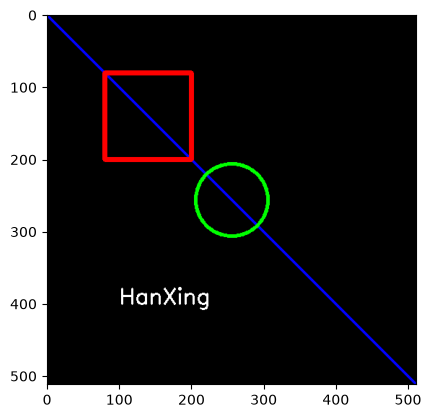

In [71]:
#创建图像
img = np.zeros((512,512,3),np.uint8)
#绘制图形
cv.line(img,(0,0),(512 ,512),(255,0,0),2)
cv.circle(img,(256,256),50,(0,255,0),4)#4:改为-1即填充图形
cv.rectangle(img,(80,80),(200,200),(0,0,255),6)
cv.putText(img,'HanXing',(100,400),cv.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)
#显示结果
plt.imshow(img[:,:,::-1])

获得并修改图像中的像素点

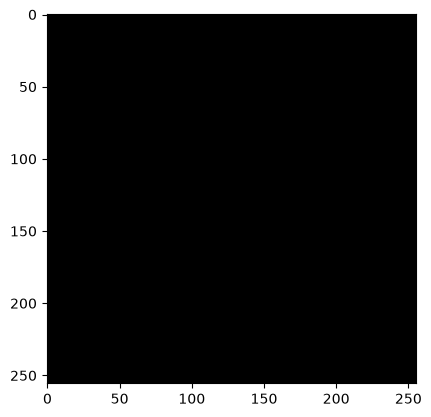

In [5]:
img = np.zeros((256,256,3),np.uint8)
plt.imshow(img[:,:,::-1])

In [6]:
img[100,100]

array([0, 0, 0], dtype=uint8)

In [7]:
img[100,100,0]#0:第0个通道 B ，1：第2个通道 G ，2：第3个通道 R

np.uint8(0)

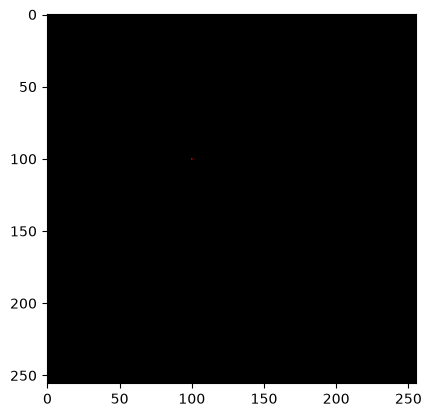

In [8]:
img[100,100] = (0,0,255)
plt.imshow(img[:,:,::-1])

10行10列的数组，100个像素点，每个像素点包括3个数字（B, G, R 的值）。演示更清晰

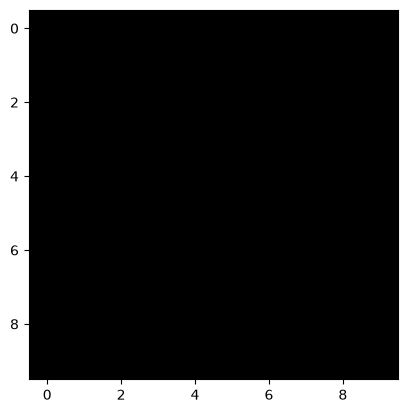

In [9]:
img1 = np.zeros((10,10,3),np.uint8)
plt.imshow(img1[:,:,::-1])

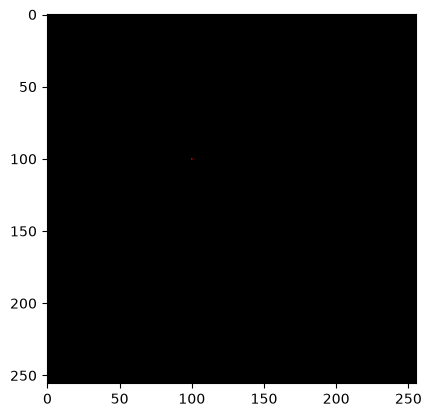

In [10]:
img1[2,2]=(0,0,255)
plt.imshow(img[:,:,::-1])

获取图像属性：行列数，通道数，数据类型，像素数等

形状：img.shape

图像大小：img.size

数据类型：img.dtype

In [11]:
img.shape

(256, 256, 3)

In [12]:
img.dtype

dtype('uint8')

In [13]:
img.size

196608

图像通道的拆分与合并

将BGR通道拆分为单个通道，或合并BGR通道

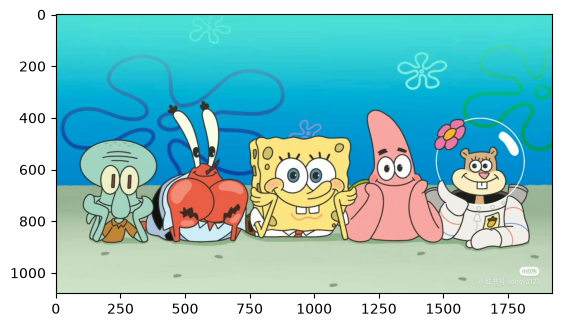

In [14]:
haimian = cv.imread('3.jpg')
plt.imshow(haimian[:,:,::-1])

In [15]:
#拆分
b,g,r = cv.split(haimian)

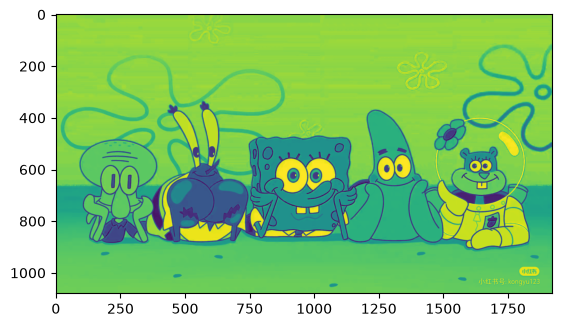

In [16]:
plt.imshow(b)

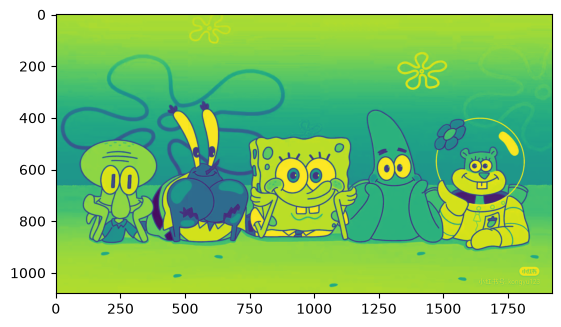

In [17]:
plt.imshow(g)

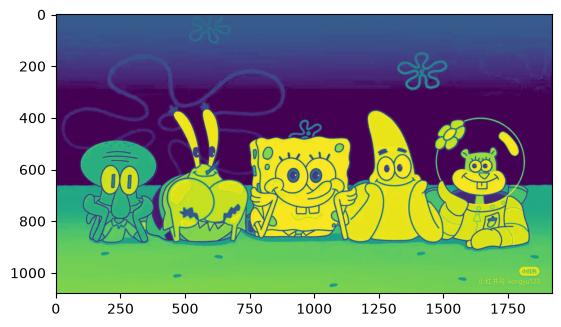

In [18]:
plt.imshow(r)

In [19]:
#合并
haimian1 = cv.merge((b,g,r))

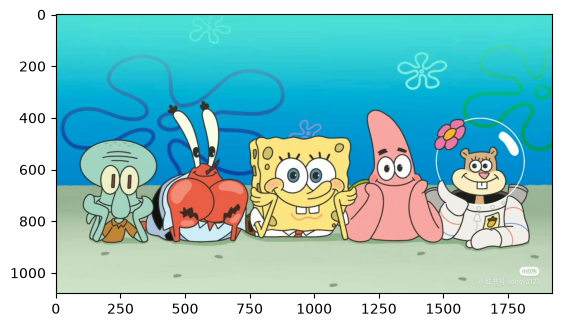

In [20]:
plt.imshow(haimian1[:,:,::-1])

色彩空间的改变

BGR<->Gray  BGR<->HSV

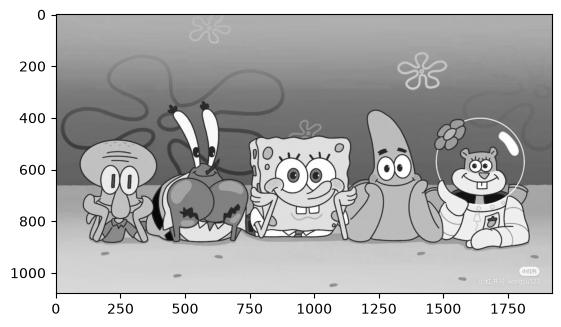

In [21]:
gray = cv.cvtColor(haimian,cv.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')

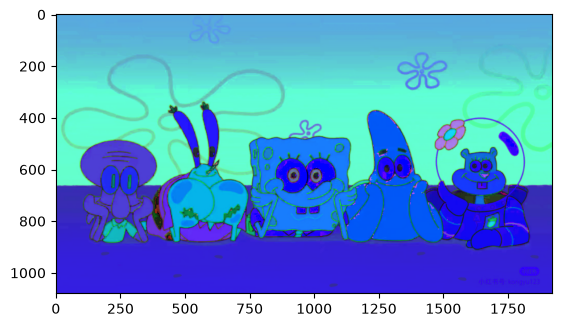

In [22]:
hsv = cv.cvtColor(haimian,cv.COLOR_BGR2HSV)
plt.imshow(hsv)

图像的算数操作

图像相加

a = cv.add(a,b) : 简单相加

图像混合

a = cv.addWeighted(baoer, 0.7, haimian1111, 0.3, 0)# 加权融合：结果 = 0.7 * baoer + 0.3 * haimian + 0

(486, 864, 3)
(1080, 1920, 3)
(486, 864, 3)
(486, 864, 3)


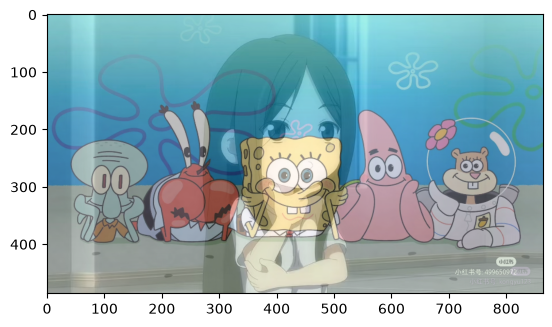

In [23]:
baoer = cv.imread('2.jpg')
haimian = cv.imread('3.jpg')

print(baoer.shape)
print(haimian.shape)

haimian1111 = cv.resize(haimian, (baoer.shape[1], baoer.shape[0]))#cv.resize 的第二个参数是 (宽度, 高度)，而 shape 是 (高度, 宽度, 通道)
print(baoer.shape)
print(haimian1111.shape)

#a = cv.add(baoer,haimian1111)
a = cv.addWeighted(baoer, 0.5, haimian1111, 0.5, 0)## 加权融合：结果 = 0.7 * baoer + 0.3 * haimian + 0
#a = baoer+haimian1111
plt.imshow(a[:,:,::-1])
plt.show()

几何变换

图像的缩放、平移、旋转等

数字图像的仿射变换、透射变换

486 864


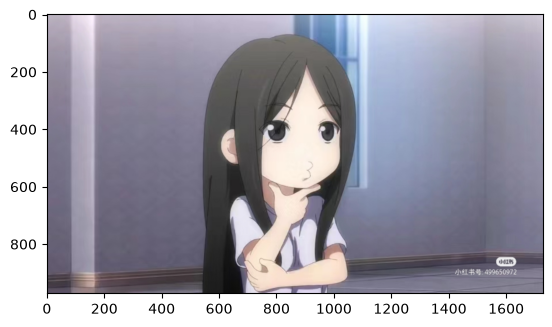

In [24]:
baoer = cv.imread('2.jpg')
#绝对尺寸——放大
rows,cols = baoer.shape[:2]
#行（rows），也就是高度
#列（cols），也就是宽度
print(rows,cols)

res = cv.resize(baoer, (2*cols, 2*rows))
#正确写法：dsize=(宽度, 高度) -> (2*cols, 2*rows)
plt.imshow(res[:,:,::-1])

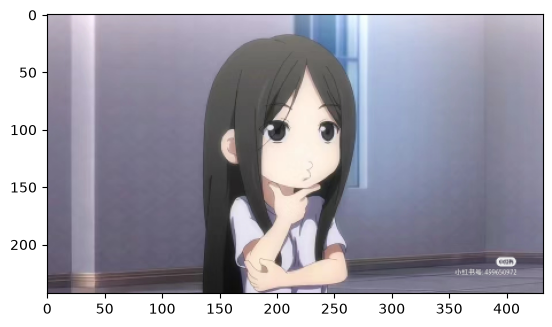

In [25]:
#相对尺寸——缩小
res1 = cv.resize(baoer, None,fx=0.5,fy=0.5,interpolation=cv.INTER_AREA)
plt.imshow(res1[:,:,::-1])

图像平移

486 864
[[  1.   0. 100.]
 [  0.   1.  50.]]


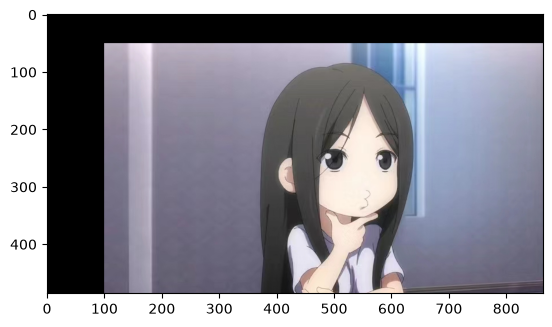

In [26]:
#plt.imshow(baoer[:,:,::-1])#原图
rows,cols = baoer.shape[:2]
print(rows,cols)

M = np.float32([[1,0,100],[0,1,50]])#tx=100,ty=50
print(M)

baoer1 = cv.warpAffine(baoer,M,(cols,rows))#(cols,rows):控制画布大小
#baoer1 = cv.warpAffine(baoer,M,(2*cols,2*rows))画布变为原来2倍
plt.imshow(baoer1[:,:,::-1])

图像旋转

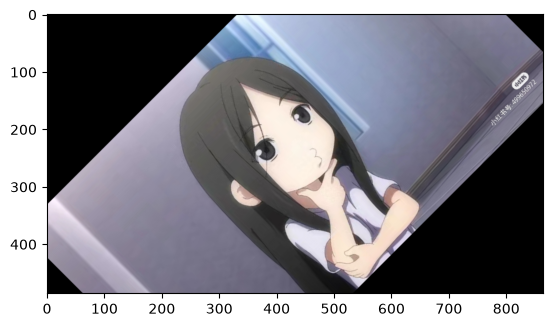

In [27]:
M = cv.getRotationMatrix2D((cols/2,rows/2),45,1)
baoer2 = cv.warpAffine(baoer,M,(cols,rows))
plt.imshow(baoer2[:,:,::-1])

仿射变换

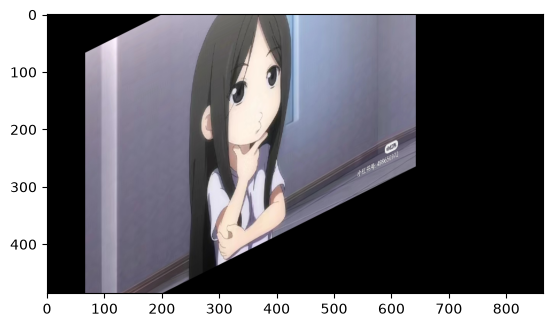

In [65]:
p1 = np.float32([[50,50],[200,50],[50,200]])
p2 = np.float32([[100,100],[200,50],[100,250]])
M = cv.getAffineTransform(p1,p2)
baoer3 = cv.warpAffine(baoer,M,(cols,rows))
plt.imshow(baoer3[:,:,::-1])

透射变换

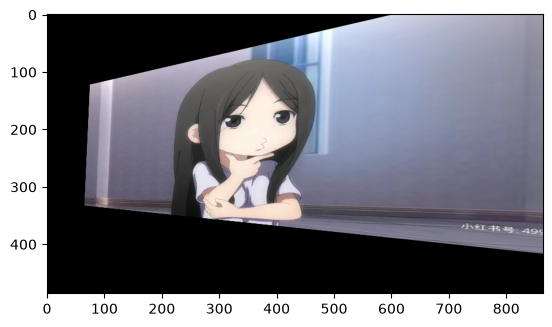

In [66]:
p1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
p2 = np.float32([[100,145],[300,100],[80,290],[310,300]])

M = cv.getPerspectiveTransform(p1,p2)
baoer4 = cv.warpPerspective(baoer,M,(cols,rows))
plt.imshow(baoer4[:,:,::-1])

图像金字塔

In [67]:
imgup = cv.pyrUp(baoer)
imgdowm = cv.pyrDown(baoer)

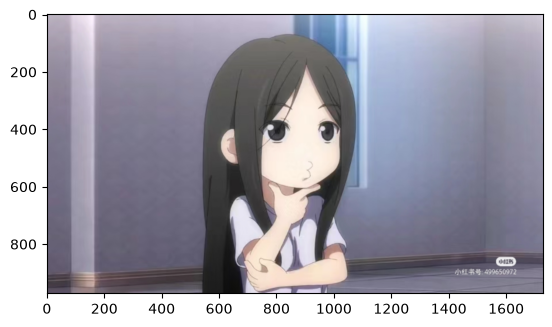

In [68]:
plt.imshow(imgup[:,:,::-1])

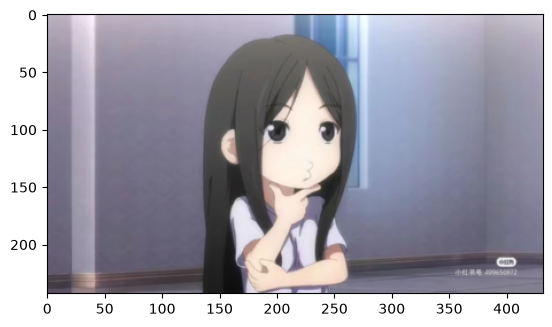

In [69]:
plt.imshow(imgdowm[:,:,::-1])

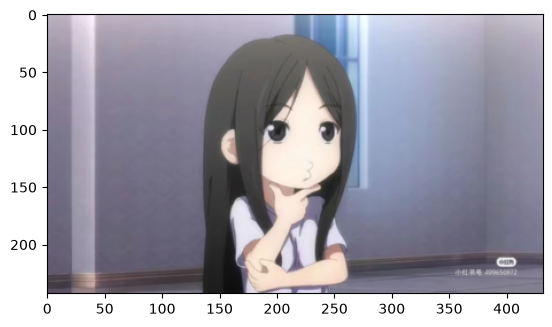

In [70]:
imgdowm1 = cv.pyrDown(baoer)
plt.imshow(imgdowm1[:,:,::-1])#分辨率越来越低

腐蚀操作

True

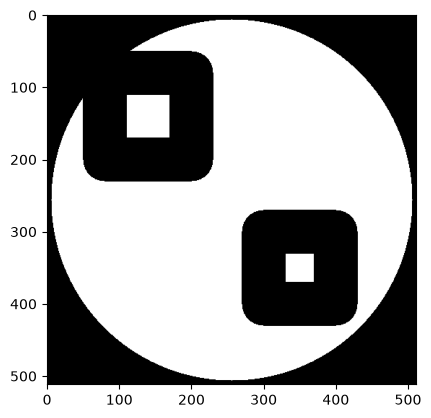

In [94]:
#创建图像
img = np.zeros((512,512,3),np.uint8)
#绘制图形

cv.circle(img,(256,256),250,(255,255,255),-1)#4:改为-1即填充图形
cv.rectangle(img,(80,80),(200,200),(0,0,0),60)
cv.rectangle(img,(300,300),(400,400),(0,0,0),60)
#显示结果
plt.imshow(img[:,:,::-1])

cv.imwrite('4.jpg',img)

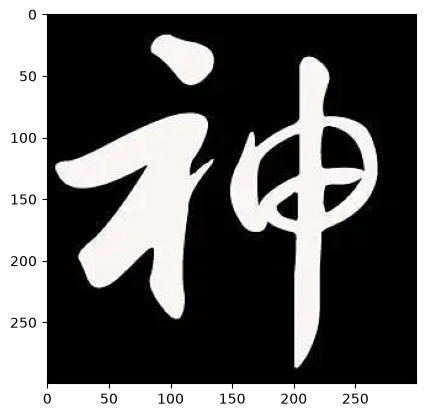

In [97]:
img = cv.imread('5.jpg')
plt.imshow(img[:,:,::-1])
#创建核结构
kernel = np.ones((5,5),np.uint8)

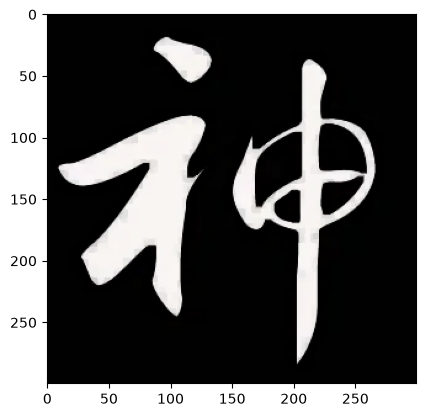

In [98]:
img2 = cv.erode(img,kernel)
plt.imshow(img2[:,:,::-1])

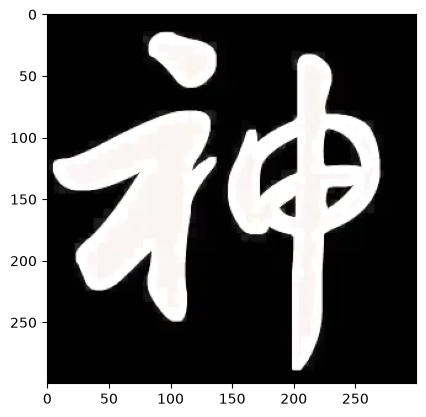

In [99]:
#膨胀操作
img3 = cv.dilate(img,kernel)
plt.imshow(img3[:,:,::-1])

s